In [12]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/elikplim/concrete-compressive-strength-data-set/concrete_data.csv


In [13]:
df = pd.read_csv("/kaggle/input/datasets/elikplim/concrete-compressive-strength-data-set/concrete_data.csv")
print(df.head())
print("Shape:", df.shape)
print("datatypes:", df.dtypes)
df.info()
#df info showed there is no null value

   cement  blast_furnace_slag  fly_ash  water  superplasticizer  \
0   540.0                 0.0      0.0  162.0               2.5   
1   540.0                 0.0      0.0  162.0               2.5   
2   332.5               142.5      0.0  228.0               0.0   
3   332.5               142.5      0.0  228.0               0.0   
4   198.6               132.4      0.0  192.0               0.0   

   coarse_aggregate  fine_aggregate   age  concrete_compressive_strength  
0            1040.0            676.0   28                          79.99  
1            1055.0            676.0   28                          61.89  
2             932.0            594.0  270                          40.27  
3             932.0            594.0  365                          41.05  
4             978.4            825.5  360                          44.30  
Shape: (1030, 9)
datatypes: cement                           float64
blast_furnace_slag               float64
fly_ash                          floa

In [14]:
print("Duplicated values:", df.duplicated().sum())
duplicates = df[df.duplicated(keep = False)]
# keep = False help to all occurance that are duplicated to happen
# example: run the code then see 72 non duplicated 77 duplicated
#so keep = false label 72 as duplicate as well therefore it is in output too
print(duplicates)#but it checks entire row of df to see if it is identical

Duplicated values: 25
     cement  blast_furnace_slag  fly_ash  water  superplasticizer  \
72    425.0               106.3      0.0  153.5              16.5   
77    425.0               106.3      0.0  153.5              16.5   
80    425.0               106.3      0.0  153.5              16.5   
83    362.6               189.0      0.0  164.9              11.6   
86    362.6               189.0      0.0  164.9              11.6   
88    362.6               189.0      0.0  164.9              11.6   
91    362.6               189.0      0.0  164.9              11.6   
95    425.0               106.3      0.0  153.5              16.5   
100   425.0               106.3      0.0  153.5              16.5   
103   425.0               106.3      0.0  153.5              16.5   
106   362.6               189.0      0.0  164.9              11.6   
109   362.6               189.0      0.0  164.9              11.6   
111   362.6               189.0      0.0  164.9              11.6   
118   425.0 

In [15]:
for column in df.columns: # we are accessing column names (df. columns)
    print(f"___{column}___")# f string helps to access variable's value
    print("unique values:", df[column].nunique())# how many different values exist
    print(df[column].unique()[:20]) # print exactly 20 unique

___cement___
unique values: 278
[540.  332.5 198.6 266.  380.  475.  427.5 190.  304.  139.6 342.  237.5
 349.  310.  485.  374.  313.3 425.  375.  469. ]
___blast_furnace_slag___
unique values: 185
[  0.  142.5 132.4 114.   95.   47.5 190.   76.  209.4  38.  237.5 189.2
 262.2 106.3  93.8 118.8 117.2  97.1 212.5  94.7]
___fly_ash___
unique values: 156
[  0.   96.7  94.6 100.5 125.4 121.6 118.3 125.2 163.3 163.8  24.5 118.2
  94.1  95.7 100.4 124.8 167.  122.  124.3  96.2]
___water___
unique values: 195
[162.  228.  192.  146.  170.1 175.5 153.5 151.4 126.6 181.1 137.8 157.9
 141.8 155.7 147.4 164.9 183.8 153.9 144.7 186. ]
___superplasticizer___
unique values: 111
[ 2.5  0.  10.1  8.6 16.5 18.6 23.4  8.9 32.2 12.1 28.2 14.3 11.4 11.6
 10.3 15.9 11.2 11.1 22.   9.5]
___coarse_aggregate___
unique values: 284
[1040.  1055.   932.   978.4 1047.   971.  1120.   926.1 1046.9  852.1
  936.   946.8  944.7  942.7 1134.3 1004.6  884.9  967.1  947.  1006.4]
___fine_aggregate ___
unique values: 3

In [16]:
numeric_cols = df.select_dtypes(include =np. number).columns 
#np. number mean select only numeric data from columns (.columns)
print(df[numeric_cols].describe(). T)# describe is used to get std, mean, max and min

                                count        mean         std     min  \
cement                         1030.0  281.167864  104.506364  102.00   
blast_furnace_slag             1030.0   73.895825   86.279342    0.00   
fly_ash                        1030.0   54.188350   63.997004    0.00   
water                          1030.0  181.567282   21.354219  121.80   
superplasticizer               1030.0    6.204660    5.973841    0.00   
coarse_aggregate               1030.0  972.918932   77.753954  801.00   
fine_aggregate                 1030.0  773.580485   80.175980  594.00   
age                            1030.0   45.662136   63.169912    1.00   
concrete_compressive_strength  1030.0   35.817961   16.705742    2.33   

                                   25%      50%       75%     max  
cement                         192.375  272.900   350.000   540.0  
blast_furnace_slag               0.000   22.000   142.950   359.4  
fly_ash                          0.000    0.000   118.300   200.1

In [17]:
correlation = df[numeric_cols].corr() # collinearity has been checked among all
print(correlation)#0=no linear relationship,-+0.1 very weak, +-0.3 weak, +-0.5 moderate
#+-0.7 strong, +-1 perfect
#+ve means direct relation adn -ve mean inverse relation but linear
# can visualize it latter if want to 

                                 cement  blast_furnace_slag   fly_ash  \
cement                         1.000000           -0.275216 -0.397467   
blast_furnace_slag            -0.275216            1.000000 -0.323580   
fly_ash                       -0.397467           -0.323580  1.000000   
water                         -0.081587            0.107252 -0.256984   
superplasticizer               0.092386            0.043270  0.377503   
coarse_aggregate              -0.109349           -0.283999 -0.009961   
fine_aggregate                -0.222718           -0.281603  0.079108   
age                            0.081946           -0.044246 -0.154371   
concrete_compressive_strength  0.497832            0.134829 -0.105755   

                                  water  superplasticizer  coarse_aggregate  \
cement                        -0.081587          0.092386         -0.109349   
blast_furnace_slag             0.107252          0.043270         -0.283999   
fly_ash                       -0

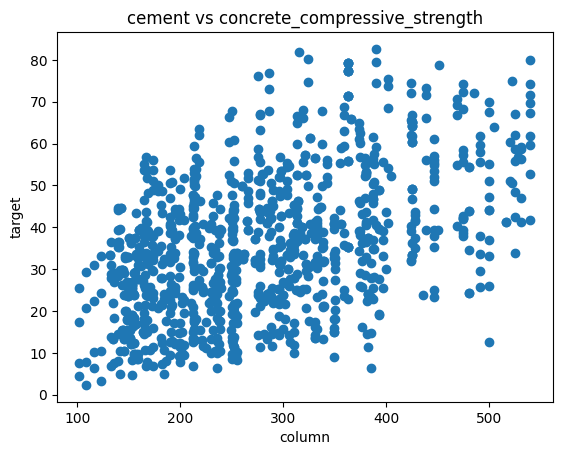

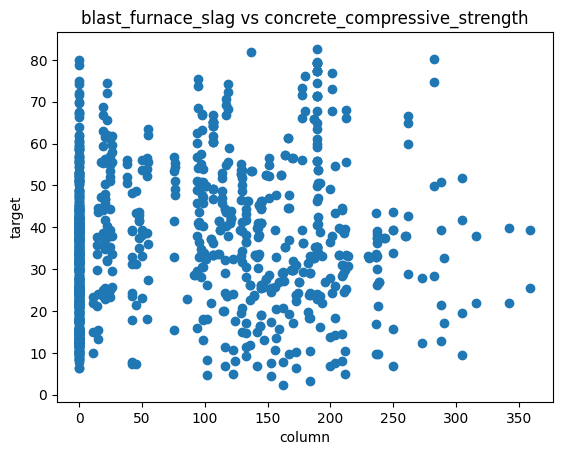

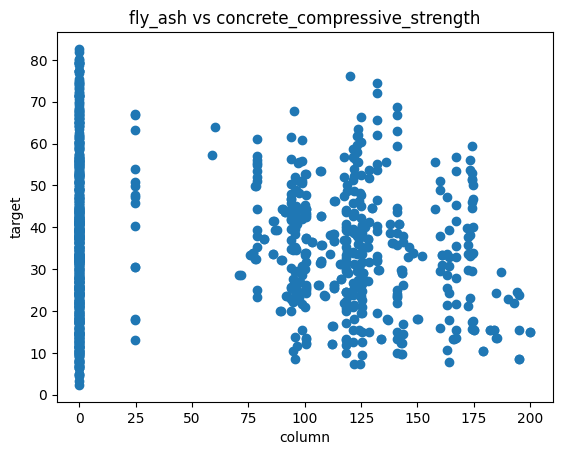

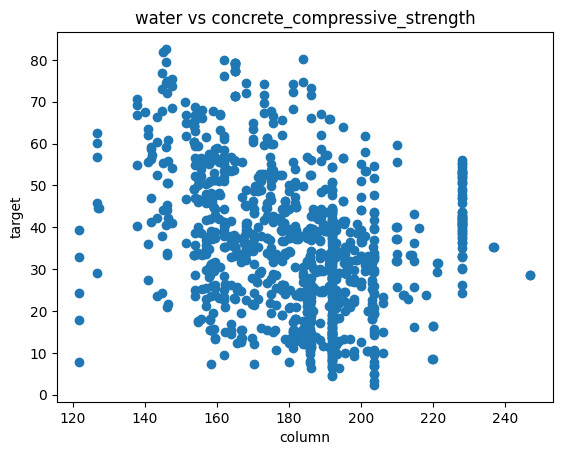

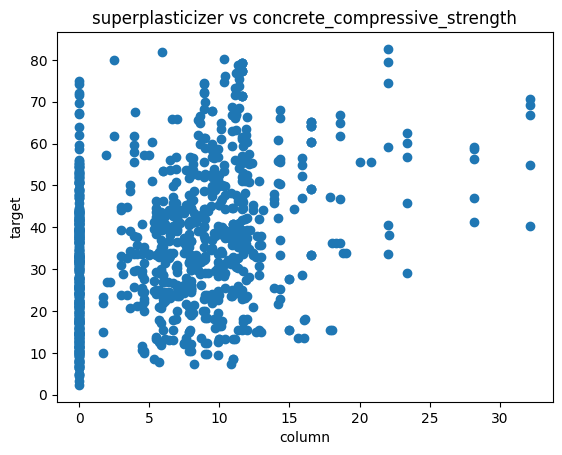

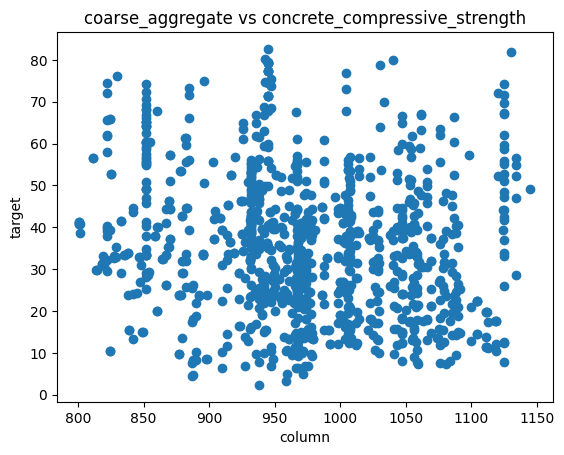

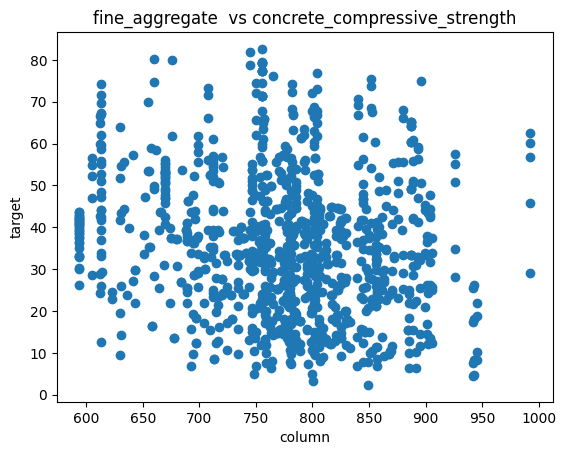

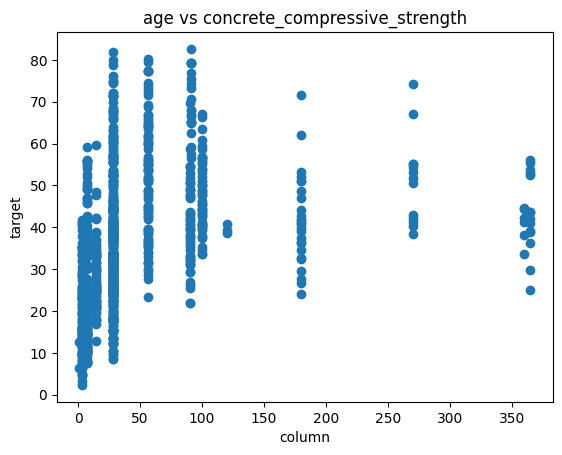

In [18]:
import matplotlib.pyplot as plt
target = "concrete_compressive_strength"
for column in numeric_cols:
    if column != target:
        plt.scatter(df[column], df[target])
        plt.xlabel("column")
        plt.ylabel("target")
        plt.title(f"{column} vs {target}")
        plt.show() # show the relationship btw response and predictors
    #remember the direction should be linear to show relation.
#but if it is scatter on whole page weak relationship is indicated


In [19]:
#checking outliers
for column in numeric_cols:
    Q1 = df[column].quantile(0.25)
    Q2 = df[column].quantile(0.75)
    IQR = Q2 - Q1 #it tells about 50% unlike previous 20% and 75%
    lower  = Q1 - 1.5*IQR #1.5 is already set by formula writer
    upper = Q2 + 1.5*IQR
    outliers = df[(df[column]<lower) | (df[column]>upper)]
    if len(outliers) > 0:
        print(f"{column}:{len(outliers)} are possible outliers")
        print("lower", lower)
        print("upper", upper)
        print("values are:")
        print(outliers[column].sort_values().to_list())
        #investigation what are the outliers values

blast_furnace_slag:2 are possible outliers
lower -214.42499999999998
upper 357.375
values are:
[359.4, 359.4]
water:9 are possible outliers
lower 124.25000000000001
upper 232.64999999999998
values are:
[121.8, 121.8, 121.8, 121.8, 121.8, 236.7, 237.0, 246.9, 247.0]
superplasticizer:10 are possible outliers
lower -15.299999999999999
upper 25.5
values are:
[28.2, 28.2, 28.2, 28.2, 28.2, 32.2, 32.2, 32.2, 32.2, 32.2]
fine_aggregate :5 are possible outliers
lower 591.3750000000001
upper 963.5749999999999
values are:
[992.6, 992.6, 992.6, 992.6, 992.6]
age:59 are possible outliers
lower -66.5
upper 129.5
values are:
[180, 180, 180, 180, 180, 180, 180, 180, 180, 180, 180, 180, 180, 180, 180, 180, 180, 180, 180, 180, 180, 180, 180, 180, 180, 180, 270, 270, 270, 270, 270, 270, 270, 270, 270, 270, 270, 270, 270, 360, 360, 360, 360, 360, 360, 365, 365, 365, 365, 365, 365, 365, 365, 365, 365, 365, 365, 365, 365]
concrete_compressive_strength:4 are possible outliers
lower -9.927500000000002
upper 

In [20]:
#check skewness (here it is not needed)
#for column in numeric_cols:
    #print(column, "skewness:", df[column].skew())
    #how asymmetric distribution is? called skewness.
    #0.5 slight right skew, 0.8 moderately right skew, 0.07 almost symmetric
    #-0.04 almost left symmetric, -0.25slight left skew
    #3.7 mean ages are concentrated towards large ages pulling distribution to right

In [25]:
#applying linear regression with test and train spilt
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
x = df[["cement","blast_furnace_slag","fly_ash", "superplasticizer", "water","coarse_aggregate", "fine_aggregate ","age"]]
y = df["concrete_compressive_strength"]
x_train, x_test,y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)
x_train = sm.add_constant(x_train)
x_test = sm.add_constant(x_test)
model = sm. OLS(y_train,x_train).fit()
y_train_pred = model.predict(x_train)
y_test_pred = model.predict(x_test)
print("training r^2:", r2_score(y_train, y_train_pred))
print("testing r^2:", r2_score(y_test, y_test_pred))
print("training rmse:", np.sqrt(mean_squared_error(y_train, y_train_pred)))
print("testing rmse:", np.sqrt(mean_squared_error(y_test, y_test_pred)))
print("training mae:", mean_absolute_error(y_train, y_train_pred))
print("testing mae:", mean_absolute_error(y_test, y_test_pred))
print("model summary:\n", model.summary())

training r^2: 0.6060321958184216
testing r^2: 0.6192417976846534
training rmse: 10.579267081142952
testing rmse: 9.905180012294709
training mae: 8.299656961699942
testing mae: 7.800302853619027
model summary:
                                   OLS Regression Results                                 
Dep. Variable:     concrete_compressive_strength   R-squared:                       0.606
Model:                                       OLS   Adj. R-squared:                  0.603
Method:                            Least Squares   F-statistic:                     179.3
Date:                           Wed, 23 Sep 2026   Prob (F-statistic):          2.60e-160
Time:                                   15:23:05   Log-Likelihood:                -3112.9
No. Observations:                            824   AIC:                             6242.
Df Residuals:                                816   BIC:                             6280.
Df Model:                                      7                      

In [22]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
x_vif = x_train.drop(columns = "const")
vif = pd.DataFrame()
vif['features'] = x_vif.columns
vif['VIF'] = [
    variance_inflation_factor(x_vif.values,i)
    #python telling go and get i in next line
    #i mean which column is being processed. .values mean these values of i 
    for i in range (x_vif.shape[1])
    #shape 1 mean column if it would be 0, it means row
    #so it is iterating over columns
]

print(vif)
#1 is no multicollinearity, 5 is fine, 10 is strong, more than 10 is severe

             features        VIF
0              cement  15.171808
1  blast_furnace_slag   3.321034
2             fly_ash   4.072001
3               water  80.978469
4    superplasticizer   5.252162
5    coarse_aggregate  82.239229
6     fine_aggregate   68.656355
7                 age   1.712463
